In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('C:/Users/Kannan T/Documents/DATA SET/customer_journey.csv')

In [5]:
df.head(10)

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0
5,session_4,user_1065,2025-04-12 23:58:16,home,Desktop,France,Social Media,49,0,0
6,session_4,user_1065,2025-04-13 00:00:31,product_page,Desktop,France,Social Media,135,4,0
7,session_5,user_2216,2025-01-08 20:58:18,home,Desktop,UK,Email,155,0,1
8,session_5,user_2216,2025-01-08 20:59:57,product_page,Desktop,UK,Email,99,0,1
9,session_5,user_2216,2025-01-08 21:00:23,cart,Desktop,UK,Email,26,5,1


In [6]:
df.drop(columns = ['SessionID', 'UserID'], axis = 1, inplace = True)

In [7]:
df.head()

,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


In [9]:
df.shape

(12719, 8)

In [12]:
df.isnull().sum()

Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64

In [13]:
df['PageType'].value_counts()

PageType
home            5000
product_page    3987
cart            1599
checkout        1123
confirmation    1010
Name: count, dtype: int64

In [14]:
df['DeviceType'].value_counts()

DeviceType
Mobile     4256
Desktop    4240
Tablet     4223
Name: count, dtype: int64

In [15]:
df['Country'].value_counts()

Country
France       1980
UK           1855
Canada       1825
USA          1808
India        1794
Germany      1738
Australia    1719
Name: count, dtype: int64

In [16]:
df['ReferralSource'].value_counts()

ReferralSource
Google          3304
Email           3212
Social Media    3115
Direct          3088
Name: count, dtype: int64

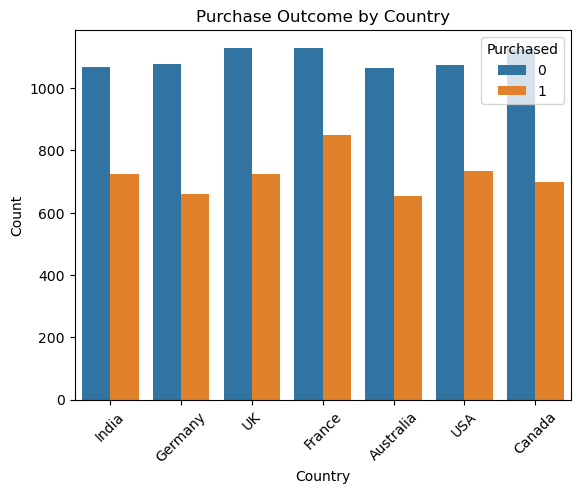

In [22]:
sns.countplot(
    data=df,
    x='Country',
    hue='Purchased'
)

plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Purchase Outcome by Country')
plt.xticks(rotation=45)
plt.show()

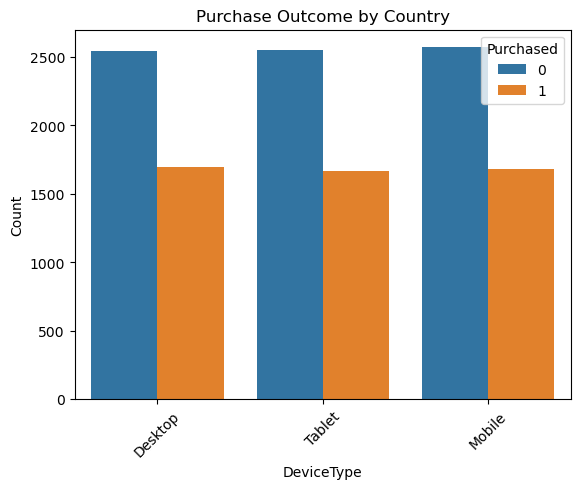

In [23]:
sns.countplot(
    data=df,
    x='DeviceType',
    hue='Purchased'
)

plt.xlabel('DeviceType')
plt.ylabel('Count')
plt.title('Purchase Outcome by Country')
plt.xticks(rotation=45)
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [29]:
df['PageType']=le.fit_transform(df['PageType'])
df['DeviceType']=le.fit_transform(df['DeviceType'])
df['Country']=le.fit_transform(df['Country'])
df['ReferralSource']=le.fit_transform(df['ReferralSource'])

In [42]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [49]:
df['hour'] = df['Timestamp'].dt.hour
df['day'] = df['Timestamp'].dt.day
df['month'] = df['Timestamp'].dt.month
df['day_of_week'] = df['Timestamp'].dt.dayofweek

In [52]:
df.drop(columns = 'Timestamp', axis = 1, inplace = True)

In [53]:
df

,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased,hour,day,month,day_of_week
0,3,0,4,3,55,0,0,22,20,1,0
1,3,2,3,1,99,0,0,12,26,2,2
2,4,2,3,1,121,0,0,12,26,2,2
3,3,1,4,2,160,0,0,15,24,6,1
4,3,2,5,2,113,0,0,7,11,6,2
...,...,...,...,...,...,...,...,...,...,...,...
12714,4,0,3,1,77,0,0,10,11,7,4
12715,3,0,3,3,57,0,0,19,27,5,1
12716,3,2,3,2,167,0,0,4,7,1,1
12717,4,2,3,2,38,2,0,4,7,1,1


In [54]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [66]:
#Think of XGBoost as building many decision trees sequentially, where each new tree tries to correct the mistakes made by the previous trees.

In [55]:
X=df.drop(columns='Purchased',axis=1)
y=df['Purchased']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [67]:
model = XGBClassifier(
    n_estimators=200, #Number of decision trees XGBoost will build.
    learning_rate=0.05, #This controls how much each new tree contributes to the final model.
    max_depth=5, #Controls the maximum depth of each decision tree.
    subsample=0.8, #This controls the percentage of training rows used by each tree.
    colsample_bytree=0.8, #Very similar idea, but instead of sampling rows, it samples features/columns.
    random_state=42, #This controls the randomness used by the algorithm.
    eval_metric='logloss' #This tells XGBoost how to evaluate its predictions during training.
)

In [58]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [59]:
y_pred = model.predict(X_test)

In [63]:
y_prob = model.predict_proba(X_test)[:,1]
y_prob

array([0.29443815, 0.8462966 , 0.1350805 , ..., 0.14745457, 0.53813815,
       0.26865688], dtype=float32)

In [71]:
#We have kept ",1" because predict_proba() returns the probability for each possible class. 
#So you'll get something like:
[[0.85, 0.15],
 [0.20, 0.80],
 [0.95, 0.05],
 [0.40, 0.60]]

# model.predict_proba(X_test)[:, 1] --> Give me the probability of class 1 (Purchase).

[[0.85, 0.15], [0.2, 0.8], [0.95, 0.05], [0.4, 0.6]]

In [70]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7838050314465409

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.92      0.84      2301
           1       0.82      0.58      0.68      1515

    accuracy                           0.78      3816
   macro avg       0.80      0.75      0.76      3816
weighted avg       0.79      0.78      0.77      3816


ROC-AUC: 0.8152681500223035

Confusion Matrix:
[[2114  187]
 [ 638  877]]


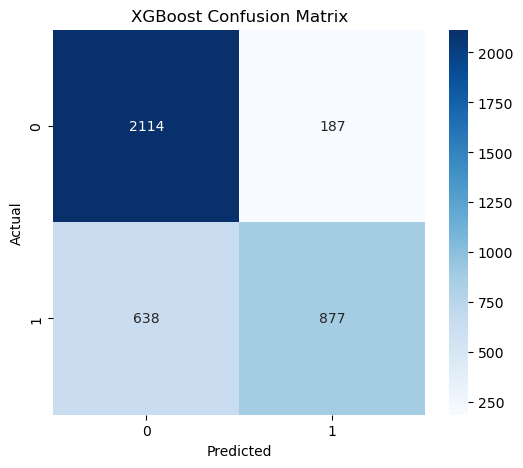

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')

plt.show()